In [4]:
!pip install tensorflow pandas matplotlib scikit-learn -q

In [5]:
import tensorflow as tf
import pandas as pd
import numpy as np

In [6]:
(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.imdb.load_data(
    num_words=10000
)

print(len(train_data))
print(len(test_data))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
25000
25000


In [7]:
word_index = tf.keras.datasets.imdb.get_word_index()

reverse_word_index = {
    value + 3: key
    for key, value in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(text):
    return " ".join(
        reverse_word_index.get(i, "?")
        for i in text
    )

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
reviews = [decode_review(x) for x in train_data[:10000]]

labels = train_labels[:10000]

df = pd.DataFrame({
    "review_text": reviews,
    "label": labels
})

df.head()

,review_text,label
0,<START> this film was just brilliant casting l...,1
1,<START> big hair big boobs bad music and a gia...,0
2,<START> this has to be one of the worst films ...,0
3,<START> the <UNK> <UNK> at storytelling the tr...,1
4,<START> worst mistake of my life br br i picke...,0


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["review_text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

In [10]:
VOCAB_SIZE = 10000

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=200
)

vectorizer.adapt(X_train)

In [11]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train.values, y_train.values)
).batch(64)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test.values, y_test.values)
).batch(64)

train_ds = train_ds.map(
    lambda x, y: (vectorizer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (vectorizer(x), y)
)

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        VOCAB_SIZE,
        32
    ),

    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["binary_accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - binary_accuracy: 0.5966 - loss: 0.6832 - val_binary_accuracy: 0.7310 - val_loss: 0.6582
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - binary_accuracy: 0.7576 - loss: 0.5914 - val_binary_accuracy: 0.7985 - val_loss: 0.5176
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.8346 - loss: 0.4348 - val_binary_accuracy: 0.8285 - val_loss: 0.4180
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.8750 - loss: 0.3348 - val_binary_accuracy: 0.8330 - val_loss: 0.3789
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.9020 - loss: 0.2740 - val_binary_accuracy: 0.8420 - val_loss: 0.3603


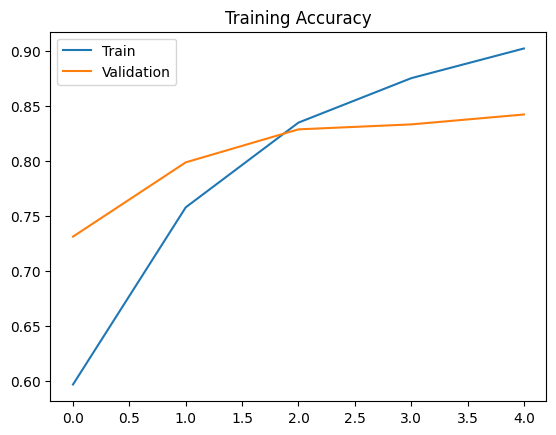

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history["binary_accuracy"])
plt.plot(history.history["val_binary_accuracy"])

plt.legend(["Train","Validation"])
plt.title("Training Accuracy")
plt.show()

In [15]:
loss, accuracy = model.evaluate(test_ds)

print("Accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8420 - loss: 0.3603
Accuracy: 0.8420000076293945


In [16]:
review = [
    "The product arrived broken and I am very unhappy"
]

prediction = model.predict(
    vectorizer(
        tf.constant(review)
    ),
    verbose=0
)

score = prediction[0][0]

print("Confidence Score:", score)

if score > 0.5:
    print("Positive")
else:
    print("Negative")

Confidence Score: 0.28821895
Negative
